# LAB 5

- Alunos:
    - Orlando Virginio Penha Junior
    - Bruno Osorio de Carvalho Almeida
    - Vinícius Ian Alves Lopes
    - Jhonata Pereira de Andrade
    - Arthur de Sousa Coelho

## Imports

In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

## Perguntas para direcionar a análise do Dataset
- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?
- 2- Qual a duração média dos processos ? E processos com mais advogados tendem a ter mais movimentações ?
- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?
- 4- Quais os tipos de defensores mais atuantes na corte, publicos ou privados? Qual tipo consegue ser mais eficiente? (Resultado diferente de culpado)
- 5- Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

## Leitura dos Dados

In [4]:
df_attorneys = load_dataset("jamiequint/sf_criminal_court", "attorneys")["train"].to_pandas()
df_calendar_jud = load_dataset("jamiequint/sf_criminal_court", "calendar_with_judicial_assignments")["train"].to_pandas()
df_cases = load_dataset("jamiequint/sf_criminal_court", "cases")["train"].to_pandas()
df_da_arrests = load_dataset("jamiequint/sf_criminal_court", "da_arrests")["train"].to_pandas()
df_da_prosecuted = load_dataset("jamiequint/sf_criminal_court", "da_prosecuted")["train"].to_pandas()
df_register = load_dataset("jamiequint/sf_criminal_court", "register_of_actions")["train"].to_pandas()
df_charge_disp = load_dataset("jamiequint/sf_criminal_court", "sfsc_charge_dispositions")["train"].to_pandas()

Generating train split: 100%|██████████| 44029/44029 [00:00<00:00, 893550.67 examples/s]


## Preprocessamento

O preprocessamento foi realizado de forma que cada integrante ficou responsável de fazer a leitura dos dataframes que possuiam relação com a sua respectiva pergunta escolhida e fazer o devido tratamento de dados.

In [5]:
dataframes = {
    'df_attorneys': df_attorneys,
    'df_calendar_jud': df_calendar_jud,
    'df_cases': df_cases,
    'df_da_arrests': df_da_arrests,
    'df_da_prosecuted': df_da_prosecuted,
    'df_register': df_register,
    'df_charge_disp': df_charge_disp
}

for nome, df in dataframes.items():
    print(f"--- info: {nome} ---")
    print(df.info())
    print("-" * 40)
    print()

--- info: df_attorneys ---
<class 'pandas.DataFrame'>
RangeIndex: 72289 entries, 0 to 72288
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             72289 non-null  int64
 1   case_number    72289 non-null  str  
 2   name           72289 non-null  str  
 3   attorney_type  72289 non-null  str  
dtypes: int64(1), str(3)
memory usage: 5.5 MB
None
----------------------------------------

--- info: df_calendar_jud ---
<class 'pandas.DataFrame'>
RangeIndex: 318993 entries, 0 to 318992
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                318993 non-null  int64  
 1   case_number                       318993 non-null  str    
 2   court_date                        318993 non-null  str    
 3   hearing_type                      318993 non-null  str    
 4   location    

### Verificar valores nulos e vazios

In [6]:
for nome, df in dataframes.items():
    print(f"--- Valores nulos em: {nome} ---")
    print(df.isna().sum())
    print("-" * 40)
    print()

--- Valores nulos em: df_attorneys ---
id               0
case_number      0
name             0
attorney_type    0
dtype: int64
----------------------------------------

--- Valores nulos em: df_calendar_jud ---
id                                     0
case_number                            0
court_date                             0
hearing_type                           0
location                               0
dept                                   0
calendar_department                    0
calendar_date                          0
assigned_judge                       675
assigned_judges                      675
assigned_judges_raw                  675
assigned_judge_canonical_key         675
assigned_judge_canonical_name        675
assigned_judges_canonical            675
assigned_judge_is_placeholder        675
has_placeholder_judge                675
judge_assignment_count               675
judge_assignment_designation         675
judge_assignment_courtroom_phone     675
judge_ass

In [7]:
for nome, df in dataframes.items():
    print(f"--- Strings vazias em: {nome} ---")
    print((df == "").sum())
    print("-" * 40)
    print()

--- Strings vazias em: df_attorneys ---
id               0
case_number      0
name             0
attorney_type    0
dtype: int64
----------------------------------------

--- Strings vazias em: df_calendar_jud ---
id                                       0
case_number                              0
court_date                               0
hearing_type                             0
location                                 0
dept                                     0
calendar_department                      0
calendar_date                            0
assigned_judge                           0
assigned_judges                          0
assigned_judges_raw                      0
assigned_judge_canonical_key             0
assigned_judge_canonical_name            0
assigned_judges_canonical                0
assigned_judge_is_placeholder            0
has_placeholder_judge                    0
judge_assignment_count                   0
judge_assignment_designation           501
judge_assign

### Tratamento dos casos

Para o preenchimendo de dados vazios em df_da_prosecuted, a estratégia utilizada foi buscar a informação em outra coluna ``list_of_filed_charges``. As linhas que não tiveram seus valores preenchidos pela coluna ``list_of_filed_charges``, por também estar com valores vazios, foram excluídas. (Orlando)

In [8]:
df_da_prosecuted['filed_case_type'].value_counts()

filed_case_type
Felony         57512
Misdemeanor    49820
MTR            12478
                1017
Name: count, dtype: int64

In [9]:
letras_extraidas = df_da_prosecuted['list_of_filed_charges'].str.extract(r'/([MF])/')[0]

dicionario_traducao = {
    'M': 'Misdemeanor',
    'F': 'Felony'
}

valores_corrigidos = letras_extraidas.map(dicionario_traducao)
linhas_vazias = df_da_prosecuted['filed_case_type'] == ''

df_da_prosecuted.loc[linhas_vazias, 'filed_case_type'] = valores_corrigidos[linhas_vazias]

In [10]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(931)

In [11]:
df_da_prosecuted = df_da_prosecuted.dropna(subset=['filed_case_type'])

In [12]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(0)

In [13]:
df_da_prosecuted['filed_case_type'].value_counts()

filed_case_type
Felony         57512
Misdemeanor    49906
MTR            12478
Name: count, dtype: int64

Algumas perguntas escolhidas envolveram a duração de tempo. Nesse sentido, se fez necessário um pré-processamento nos dataframes que apresentavam informações de data, como as tabelas de **df_attorneys**, **df_register**, **df_calendar_jud** e **df_charge_disp**

In [14]:
df_cases['filed_date'] = pd.to_datetime(df_cases['filed_date'], errors='coerce')
df_cases['scraped_at'] = pd.to_datetime(df_cases['scraped_at'], errors='coerce')

# Diferença entre a data de scraping e a abertura do processo
# (não há coluna de encerramento; scraped_at representa o momento mais recente registrado)
df_cases['duracao_dias'] = (df_cases['scraped_at'] - df_cases['filed_date']).dt.days

df_cases.head()

,case_number,case_id,defendant_name,filed_date,scraped_at,duracao_dias
0,CRI25000001,4161165,CHANTAIL L MYLES,2025-01-02,2026-03-20 22:52:53.372069,442.0
1,CRI25000005,4161163,DAJCHA JNALASHAY LANDERS,2025-02-28,2026-03-20 22:57:56.233258,385.0
2,CRI25000007,4161183,JOHN MARSHALL THORNTON,NaT,2026-03-20 22:58:17.392932,NaN
3,CRI25000008,4161184,CATHERINE MICHELLE WHITE,2025-01-06,2026-03-20 22:58:43.779784,438.0
4,CRI25000009,4161185,IDRISSA O SOW,NaT,2026-03-20 22:58:50.308604,NaN


In [15]:
df_cases['duracao_dias'].isna().sum()

np.int64(51984)

Analisando o dataframe de calendário com juízes, percebemos muitos valores nulos na coluna 'assigned_judge_canonical_name'. Decidimos remover as linhas onde essa coluna é nula.

In [16]:
df_calendar_jud['assigned_judge_canonical_name'].isna().sum()

np.int64(675)

In [17]:
df_calendar_jud = df_calendar_jud[~df_calendar_jud['assigned_judge_canonical_name'].isna()]
df_calendar_jud['assigned_judge_canonical_name'].isna().sum()

np.int64(0)

In [18]:
df_calendar_jud['calendar_date'] = pd.to_datetime(
    df_calendar_jud['calendar_date']
)

In [19]:
df_charge_disp['dispo_date'] = pd.to_datetime(
    df_charge_disp['dispo_date']
)

In [20]:
print('Nulos em assigned_judge_canonical_name:', df_calendar_jud['assigned_judge_canonical_name'].isna().sum())
print('Nulos em calendar_date:', df_calendar_jud['calendar_date'].isna().sum())
print('Nulos em dispo_date:', df_charge_disp['dispo_date'].isna().sum())

Nulos em assigned_judge_canonical_name: 0
Nulos em calendar_date: 0
Nulos em dispo_date: 19538


Para a pergunta 4, as informações necessárias para respondê-a, estão em 3 df diferentes: 
- df_attorneys 
- df_cases
- df_charge_disp

(Bruno)

In [21]:
df_attorneys = df_attorneys[df_attorneys["attorney_type"] != "District Attorney"]
df_attorneys.value_counts('attorney_type')

attorney_type
Public Defender          22571
Conflict Attorney         5708
Private Counsel           1249
Primary                    465
Private Attorney           362
Appointed Attorney         127
Self Represented            38
Appointed Counsel           30
Standby Counsel              9
Co-Counsel                   8
Self-Represented             7
Defense Attorney             5
Prosecuting Authority        3
Attorney General             2
Name: count, dtype: int64

- Na etapa de pré-processamento, identificou-se que algumas classes de advogados possuíam uma quantidade irrelevante para o escopo do problema, atuando apenas como ruído (ex: Appointed Attorney, Standby Counsel e Self-Represented). Após a exclusão dessas linhas, os dados foram consolidados em duas categorias principais para responder à pergunta central do negócio:

Public: Advogados de natureza pública e custeados pelo Estado (ex: Defensoria Pública).

Private: Advogados de iniciativa privada, incluindo os profissionais particulares contratados de forma independente e os Conflict Attorneys (advogados privados nomeados e pagos pelo tribunal para casos específicos).

In [22]:
valores_para_excluir = ['Appointed Attorney', 'Appointed Counsel', 'Standby Counsel', 'Self-Represented', 'Self Represented']
df_attorneys = df_attorneys[~df_attorneys['attorney_type'].isin(valores_para_excluir)]

mapping = {
    # Natureza Pública
    'Public Defender': 'public','Prosecuting Authority': 'public','Attorney General': 'public',
    
    # Natureza Privada
    'Conflict Attorney': 'private','Private Counsel': 'private','Private Attorney': 'private','Primary': 'private','Co-Counsel': 'private','Defense Attorney': 'private'
}

df_attorneys['attorney_type'] = df_attorneys['attorney_type'].map(mapping)

df_attorneys.head()

,id,case_number,name,attorney_type
0,6,CRI25000008,Sarah Hashemi,public
1,7,CRI25000008,Liliana Garcia,public
3,9,CRI25000012,MELISSA SHEILA LUBIN,private
4,10,CRI25000012,Conflicts Counsel,public
5,11,CRI25000012,Diamond Ward,public


Para a pergunta que envolve análise de sazonalidade no Tribunal Criminal de São Francisco, foi necessário mais processamentos dentro do dataset **df_cases**. (Arthur)

In [23]:
df_cases['filed_date'] = pd.to_datetime(df_cases['filed_date'], errors='coerce')

df_cases['mes_abertura'] = df_cases['filed_date'].dt.month
df_cases['ano_abertura'] = df_cases['filed_date'].dt.year

df_cases[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

,case_number,filed_date,mes_abertura,ano_abertura
0,CRI25000001,2025-01-02,1.0,2025.0
1,CRI25000005,2025-02-28,2.0,2025.0
2,CRI25000007,NaT,NaN,NaN
3,CRI25000008,2025-01-06,1.0,2025.0
4,CRI25000009,NaT,NaN,NaN


In [25]:
print("Valores nulos")
print(f"{df_cases['filed_date'].isna().sum()/len(df_cases) * 100:.2f}% dos dados")

Valores nulos
67.16% dos dados


In [26]:
df_register['filed_date'] = pd.to_datetime(df_register['filed_date'], errors='coerce')
primeiras_datas = df_register.groupby('case_number')['filed_date'].min()
primeiras_datas = primeiras_datas.dt.tz_localize(None).dt.normalize()
df_cases['filed_date'] = df_cases['filed_date'].fillna(df_cases['case_number'].map(primeiras_datas))
df_cases['mes_abertura'] = df_cases['filed_date'].dt.month
df_cases['ano_abertura'] = df_cases['filed_date'].dt.year
df_cases[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

,case_number,filed_date,mes_abertura,ano_abertura
0,CRI25000001,2025-01-02,1.0,2025.0
1,CRI25000005,2025-02-28,2.0,2025.0
2,CRI25000007,2025-01-02,1.0,2025.0
3,CRI25000008,2025-01-06,1.0,2025.0
4,CRI25000009,NaT,NaN,NaN


In [28]:
print("Valores nulos")
print(f"{df_cases['filed_date'].isna().sum()/len(df_cases) * 100:.2f}% dos dados")

Valores nulos
57.37% dos dados


Como ainda existiram dados nulos após o preenchimento de dados com a tabela de ***df_register***, isso significa que as informações também não existe, na tabela df_register (ou, se existe, a data dele também estava em branco lá).

Dessa forma, optou-se por excluir os dados dessa tabela que estivessem nulos, objetivando focar na pergunta a ser respondida sobre a análise de sazonalidade no tribunal criminal de São Francisco

In [30]:
df_cases = df_cases.dropna(subset=['filed_date'])
df_cases[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

,case_number,filed_date,mes_abertura,ano_abertura
0,CRI25000001,2025-01-02,1.0,2025.0
1,CRI25000005,2025-02-28,2.0,2025.0
2,CRI25000007,2025-01-02,1.0,2025.0
3,CRI25000008,2025-01-06,1.0,2025.0
7,CRI25000012,2025-01-03,1.0,2025.0


In [32]:
print("Valores nulos")
print(f"{df_cases['filed_date'].isna().sum()/len(df_cases) * 100:.2f}% dos dados")

Valores nulos
0.00% dos dados


## EDA

Observa-se que a polícia classifica a maior parte das prisões como Felony, e a promotoria também mantém Felony como a categoria mais frequente nos casos formalizados. Ainda assim, há uma diferença relevante no volume de Misdemeanor entre as duas etapas, indicando que parte dos casos pode ser reclassificada no processo de acusação.

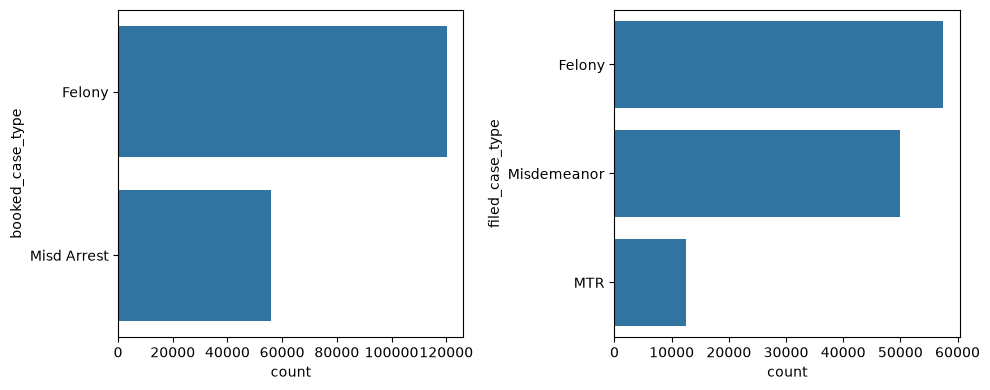

In [33]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.barplot(df_da_arrests.value_counts('booked_case_type'),orient='h',ax=axes[0])
sns.barplot(df_da_prosecuted.value_counts('filed_case_type'),orient='h',ax=axes[1])
plt.tight_layout()

Vamos analisar a duração dos processos e como ela se relaciona com a quantidade de advogados e movimentações.

In [34]:
df_cases_validos = df_cases.dropna(subset=['duracao_dias'])

df_mov = (
    df_register
    .groupby('case_number', as_index=False)
    .size()
    .rename(columns={'size': 'qtd_movimentacoes'})
)

df_adv = (
    df_attorneys
    .groupby('case_number', as_index=False)
    .size()
    .rename(columns={'size': 'qtd_advogados'})
)

df_p2 = (
    df_cases_validos[['case_number', 'duracao_dias']]
    .merge(df_mov, on='case_number', how='left')
    .merge(df_adv, on='case_number', how='left')
)

df_p2['qtd_movimentacoes'] = df_p2['qtd_movimentacoes'].fillna(0).astype(int)
df_p2['qtd_advogados'] = df_p2['qtd_advogados'].fillna(0).astype(int)

df_p2['faixa_advogados'] = df_p2['qtd_advogados'].apply(
    lambda n: '0' if n == 0 else '1' if n == 1 else '2' if n == 2 else '3+'
)

print(f"Total de processos válidos para análise da pergunta 2: {len(df_p2):,}")

Total de processos válidos para análise da pergunta 2: 25,422


O histograma mostra o perfil geral da duração dos processos, enquanto o boxplot compara a duração entre faixas de quantidade de advogados.

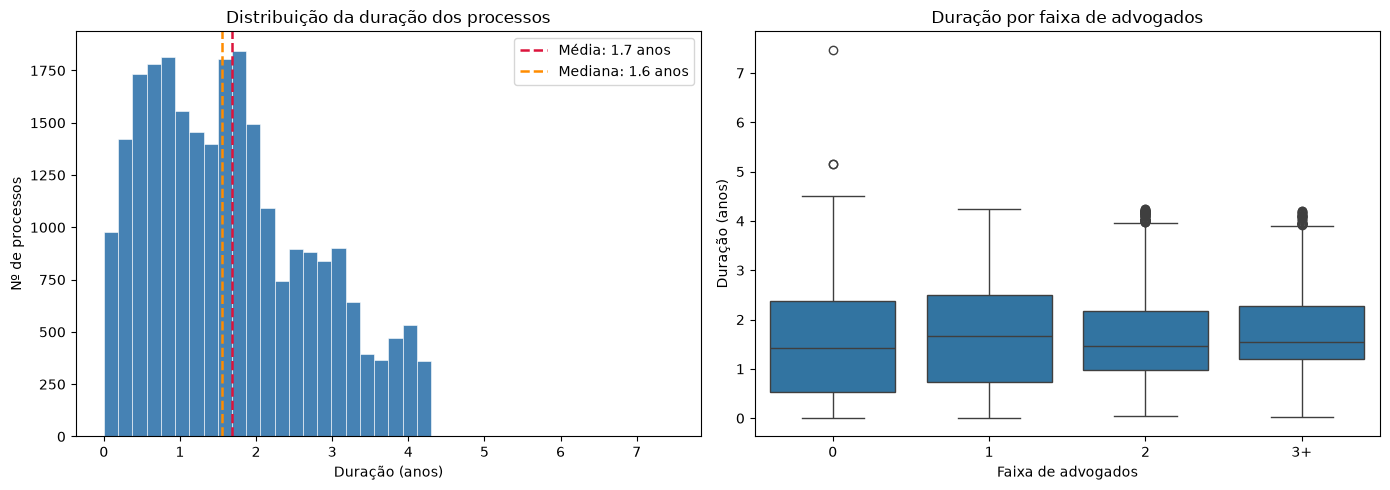

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

duracao_anos = df_p2['duracao_dias'] / 365
media = duracao_anos.mean()
mediana = duracao_anos.median()

axes[0].hist(duracao_anos, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(media, color='crimson', linestyle='--', lw=1.8, label=f'Média: {media:.1f} anos')
axes[0].axvline(mediana, color='darkorange', linestyle='--', lw=1.8, label=f'Mediana: {mediana:.1f} anos')
axes[0].set_title('Distribuição da duração dos processos')
axes[0].set_xlabel('Duração (anos)')
axes[0].set_ylabel('Nº de processos')
axes[0].legend()

ordem = ['0', '1', '2', '3+']
sns.boxplot(data=df_p2, x='faixa_advogados', y=duracao_anos, order=ordem, ax=axes[1])
axes[1].set_title('Duração por faixa de advogados')
axes[1].set_xlabel('Faixa de advogados')
axes[1].set_ylabel('Duração (anos)')

plt.tight_layout()
plt.show()

Aqui verificamos se processos com mais advogados tendem a ter mais movimentações ao longo do andamento.

/var/folders/s_/nn4x_yhx3n70jk52dq4ylgnh0000gn/T/ipykernel_42227/396780457.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumo_mov, x='faixa_advogados', y='qtd_movimentacoes', ax=axes[0], palette='Blues')


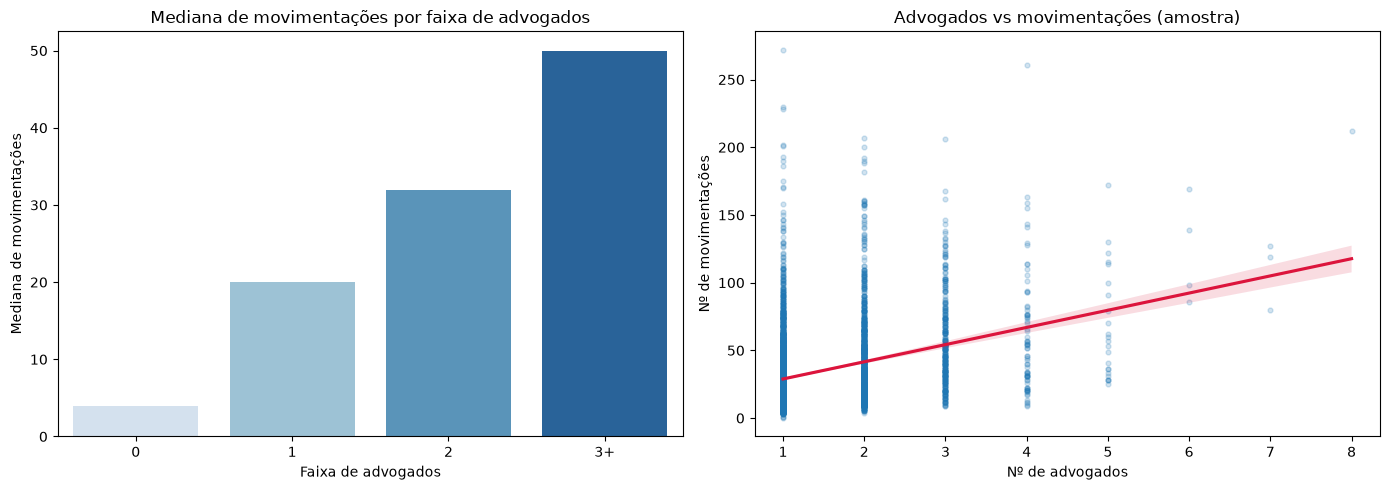

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumo_mov = (
    df_p2.groupby('faixa_advogados')['qtd_movimentacoes']
    .median()
    .reindex(['0', '1', '2', '3+'])
    .reset_index()
)

sns.barplot(data=resumo_mov, x='faixa_advogados', y='qtd_movimentacoes', ax=axes[0], palette='Blues')
axes[0].set_title('Mediana de movimentações por faixa de advogados')
axes[0].set_xlabel('Faixa de advogados')
axes[0].set_ylabel('Mediana de movimentações')

amostra = df_p2[df_p2['qtd_advogados'] > 0].sample(min(4000, len(df_p2)), random_state=42)
sns.regplot(
    data=amostra,
    x='qtd_advogados',
    y='qtd_movimentacoes',
    scatter_kws={'alpha': 0.2, 's': 12},
    line_kws={'color': 'crimson'},
    ax=axes[1]
)
axes[1].set_title('Advogados vs movimentações (amostra)')
axes[1].set_xlabel('Nº de advogados')
axes[1].set_ylabel('Nº de movimentações')

plt.tight_layout()
plt.show()

Como neste notebook não estamos criando o `df_result`, os gráficos foram adaptados para usar diretamente os dataframes já pré-processados.

In [37]:
df_p3_span = (
    df_calendar_jud
    .groupby('case_number')
    .agg(
        first_date=('calendar_date', 'min'),
        last_date=('calendar_date', 'max'),
        judge=('assigned_judge_canonical_name', lambda x: x.mode().iloc[0] if not x.mode().empty else x.dropna().iloc[0])
    )
    .reset_index()
)

df_p3_span['span_days'] = (df_p3_span['last_date'] - df_p3_span['first_date']).dt.days

Este boxplot compara a duração (intervalo de calendário) dos casos entre os juízes com mais casos registrados.

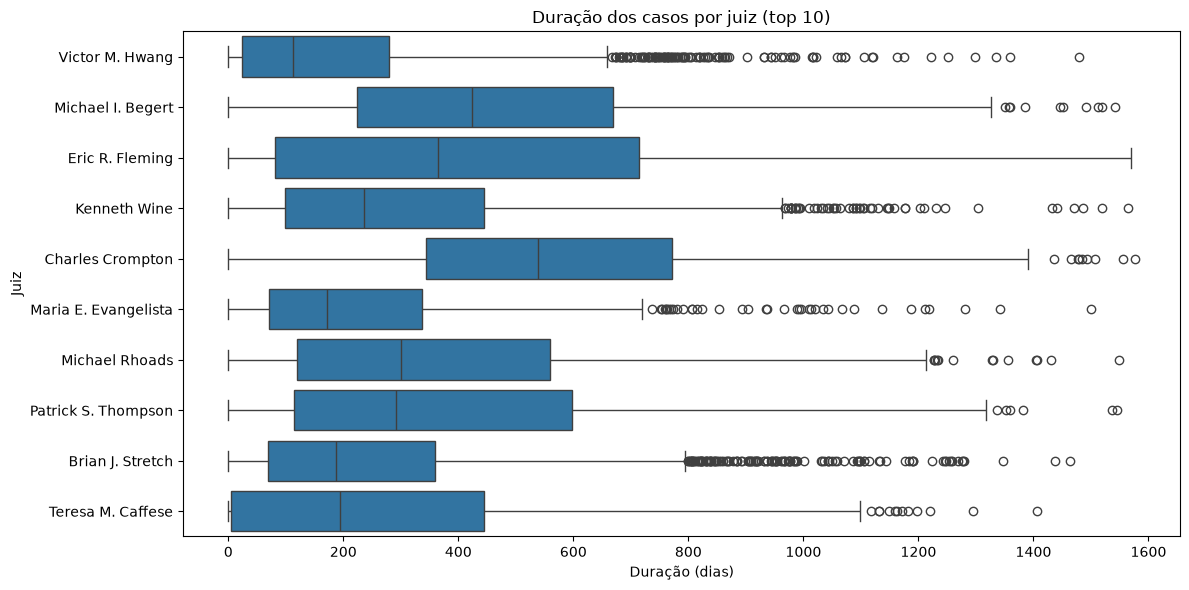

In [38]:
top_judges_p3 = df_p3_span['judge'].value_counts().head(10).index
box_df_p3 = df_p3_span[df_p3_span['judge'].isin(top_judges_p3)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=box_df_p3, x='span_days', y='judge')
plt.title('Duração dos casos por juiz (top 10)')
plt.xlabel('Duração (dias)')
plt.ylabel('Juiz')
plt.tight_layout()
plt.show()

O gráfico abaixo mostra os tipos de crime mais frequentes no conjunto de disposições.

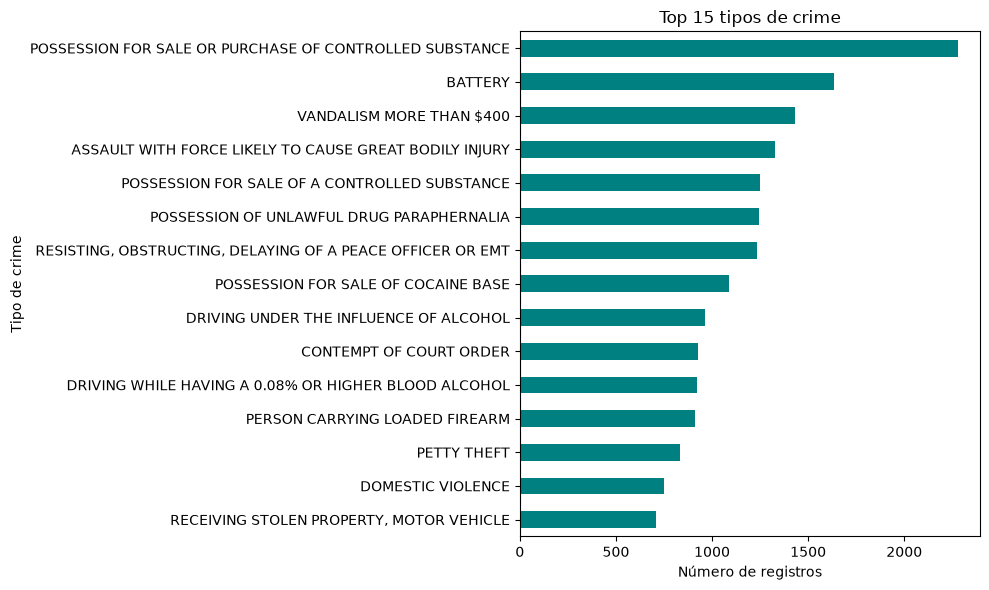

In [39]:
top_crimes_p3 = df_charge_disp['statute_description'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_crimes_p3.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 tipos de crime')
plt.xlabel('Número de registros')
plt.ylabel('Tipo de crime')
plt.tight_layout()
plt.show()

Este gráfico traz os advogados mais recorrentes, útil para investigar concentração de atuação em casos mais longos.

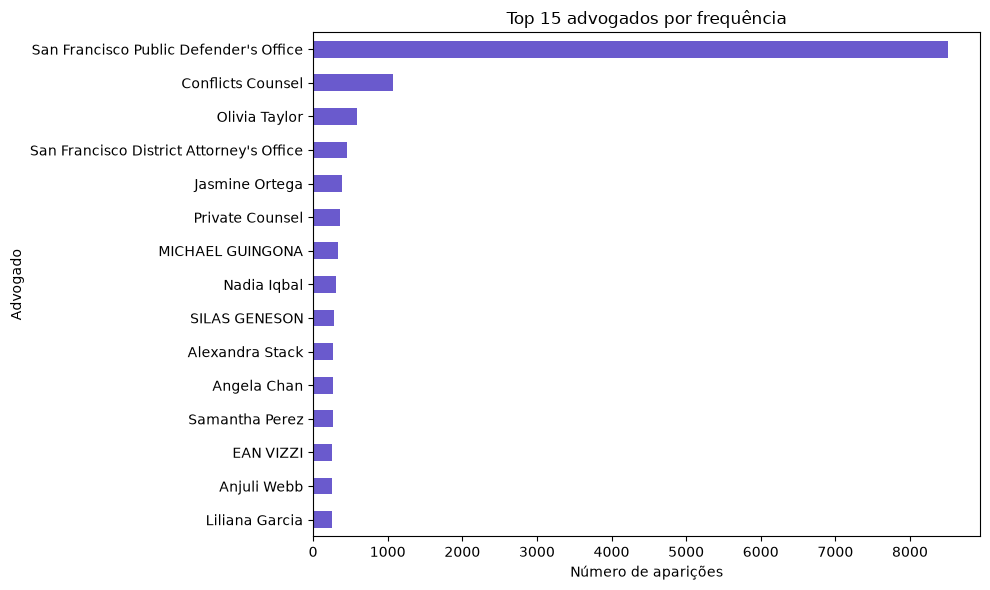

In [40]:
top_attorneys_p3 = df_attorneys['name'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_attorneys_p3.sort_values().plot(kind='barh', color='slateblue')
plt.title('Top 15 advogados por frequência')
plt.xlabel('Número de aparições')
plt.ylabel('Advogado')
plt.tight_layout()
plt.show()

Nesta etapa, avaliamos atuação e eficiência entre defesa pública e privada com base nos dados já tratados.

In [41]:
df_p4 = (
    df_attorneys[['case_number', 'attorney_type']]
    .merge(
        df_charge_disp[['case_number', 'charge_type_initial', 'dispo_type']],
        on='case_number',
        how='inner'
    )
)

df_p4 = df_p4.dropna(subset=['attorney_type', 'dispo_type'])

status_culpado = ['guilty', 'convicted']
df_p4['favoravel'] = ~df_p4['dispo_type'].str.lower().str.contains('|'.join(status_culpado), na=False)

print(f"Total de registros para análise da pergunta 4: {len(df_p4):,}")

Total de registros para análise da pergunta 4: 40,092


Primeiro, observamos qual tipo de defensor aparece com mais frequência nos casos analisados.

/var/folders/s_/nn4x_yhx3n70jk52dq4ylgnh0000gn/T/ipykernel_42227/530313003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=atuacao_p4, x='attorney_type', y='total_registros', palette='Blues_d')


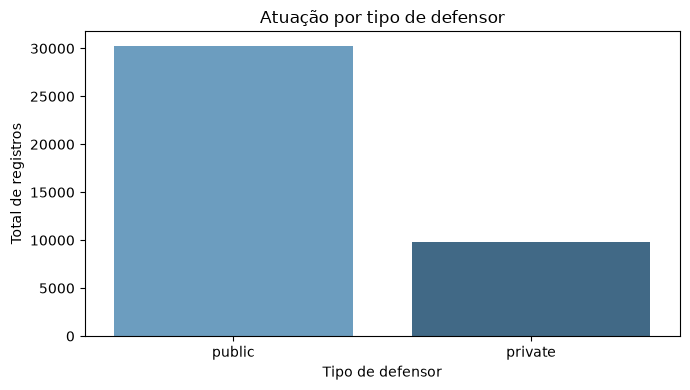

In [42]:
atuacao_p4 = df_p4['attorney_type'].value_counts().reset_index()
atuacao_p4.columns = ['attorney_type', 'total_registros']

plt.figure(figsize=(7, 4))
sns.barplot(data=atuacao_p4, x='attorney_type', y='total_registros', palette='Blues_d')
plt.title('Atuação por tipo de defensor')
plt.xlabel('Tipo de defensor')
plt.ylabel('Total de registros')
plt.tight_layout()
plt.show()

Aqui comparamos, de forma geral, a taxa de desfechos favoráveis entre defensores públicos e privados.

/var/folders/s_/nn4x_yhx3n70jk52dq4ylgnh0000gn/T/ipykernel_42227/3502375966.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=taxa_geral_p4, x='attorney_type', y='taxa_favoravel', palette='Blues_d')


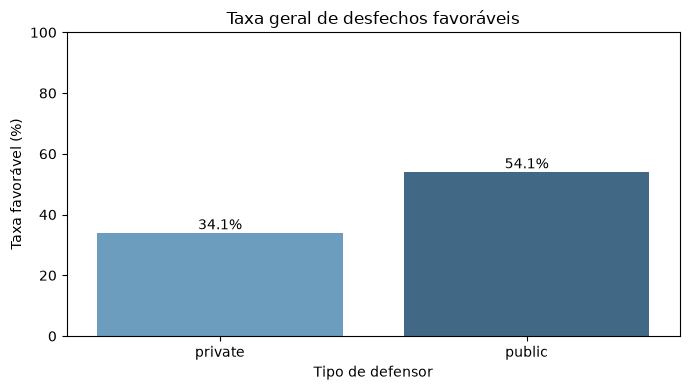

In [43]:
taxa_geral_p4 = (
    df_p4.groupby('attorney_type')['favoravel']
    .mean()
    .mul(100)
    .reset_index(name='taxa_favoravel')
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=taxa_geral_p4, x='attorney_type', y='taxa_favoravel', palette='Blues_d')

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.title('Taxa geral de desfechos favoráveis')
plt.xlabel('Tipo de defensor')
plt.ylabel('Taxa favorável (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Este gráfico detalha a taxa favorável por tipo de crime inicial, destacando os crimes mais frequentes.

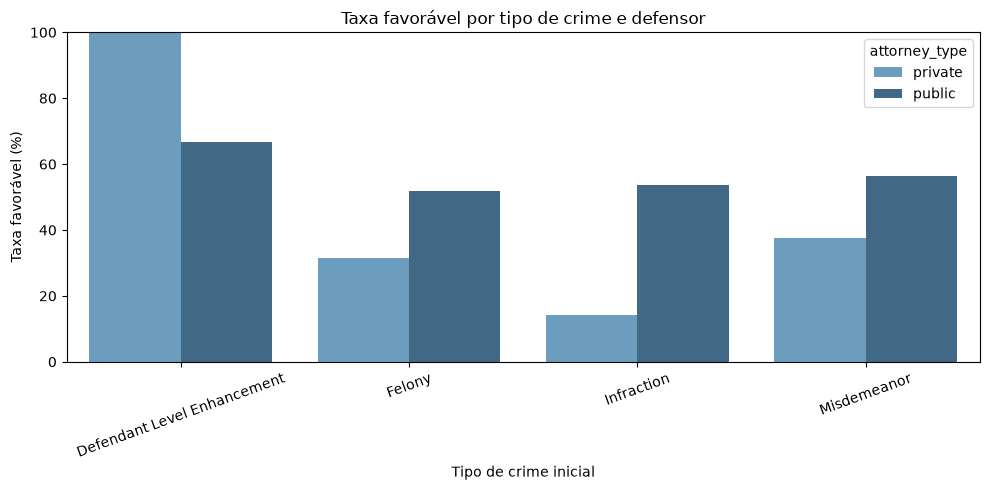

In [44]:
top_crimes_p4 = df_p4['charge_type_initial'].value_counts().head(6).index

df_p4_plot = df_p4[df_p4['charge_type_initial'].isin(top_crimes_p4)]

taxa_crime_p4 = (
    df_p4_plot.groupby(['charge_type_initial', 'attorney_type'])['favoravel']
    .mean()
    .mul(100)
    .reset_index(name='taxa_favoravel')
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=taxa_crime_p4,
    x='charge_type_initial',
    y='taxa_favoravel',
    hue='attorney_type',
    palette='Blues_d'
)
plt.title('Taxa favorável por tipo de crime e defensor')
plt.xlabel('Tipo de crime inicial')
plt.ylabel('Taxa favorável (%)')
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Vamos observar possíveis padrões sazonais no volume de abertura de processos ao longo dos meses.

In [45]:
casos_por_ano_mes = (
    df_cases.dropna(subset=['ano_abertura', 'mes_abertura'])
    .groupby(['ano_abertura', 'mes_abertura'])
    .size()
    .reset_index(name='total_casos')
)

casos_por_ano_mes['ano_abertura'] = casos_por_ano_mes['ano_abertura'].astype(int)
casos_por_ano_mes['mes_abertura'] = casos_por_ano_mes['mes_abertura'].astype(int)

casos_por_ano_mes['data_plot'] = pd.to_datetime(
    casos_por_ano_mes['ano_abertura'].astype(str) + '-' + casos_por_ano_mes['mes_abertura'].astype(str) + '-01'
)

media_por_mes = (
    casos_por_ano_mes
    .groupby('mes_abertura')['total_casos']
    .mean()
    .reset_index(name='media_casos')
)

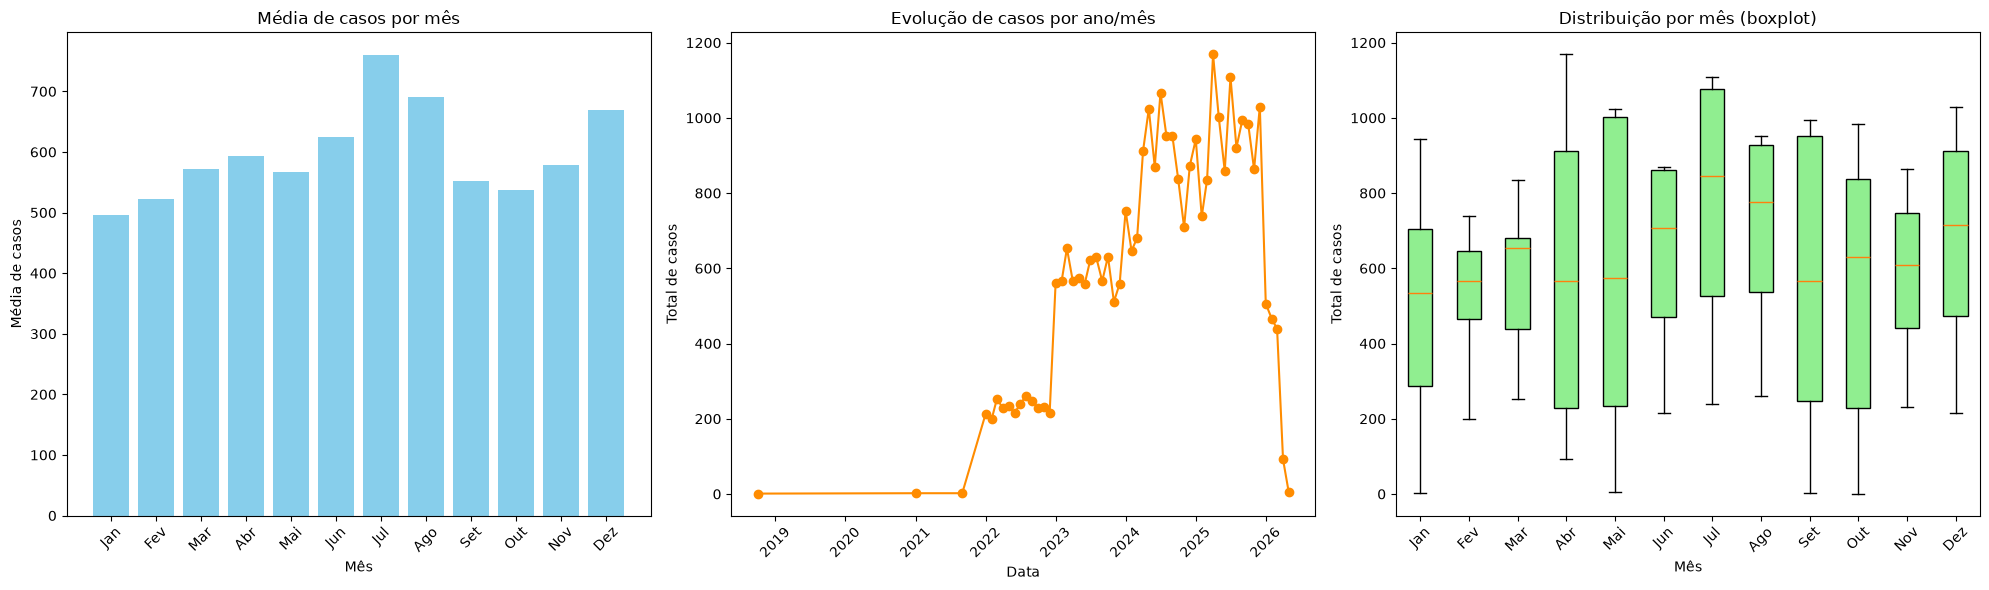

In [47]:
# Séries de abertura por ano/mês (dados válidos)
cases_sazonal = df_cases.dropna(subset=['filed_date']).copy()
cases_sazonal['ano_abertura'] = cases_sazonal['ano_abertura'].astype(int)
cases_sazonal['mes_abertura'] = cases_sazonal['mes_abertura'].astype(int)

casos_por_ano_mes = (
    cases_sazonal
    .groupby(['ano_abertura', 'mes_abertura'])['case_number']
    .nunique()
    .reset_index(name='total_casos')
)

casos_por_ano_mes['data_plot'] = pd.to_datetime(
    casos_por_ano_mes['ano_abertura'].astype(str)
    + '-'
    + casos_por_ano_mes['mes_abertura'].astype(str).str.zfill(2)
    + '-01'
)

meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 5.1: média de casos por mês
media_mensal = (
    casos_por_ano_mes
    .groupby('mes_abertura')['total_casos']
    .mean()
    .reindex(range(1, 13), fill_value=0)
)
axes[0].bar(range(1, 13), media_mensal.values, color='skyblue')
axes[0].set_title('Média de casos por mês')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_labels, rotation=45)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Média de casos')

# Gráfico 5.2: evolução temporal
axes[1].plot(casos_por_ano_mes['data_plot'], casos_por_ano_mes['total_casos'], marker='o', color='darkorange')
axes[1].set_title('Evolução de casos por ano/mês')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Total de casos')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 5.3: boxplot por mês
dados_boxplot = [
    casos_por_ano_mes[casos_por_ano_mes['mes_abertura'] == i]['total_casos'].values
    for i in range(1, 13)
]
axes[2].boxplot(dados_boxplot, tick_labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('Distribuição por mês (boxplot)')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Total de casos')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Os gráficos de sazonalidade mostram variação mensal no volume de aberturas, com períodos de maior e menor concentração de casos ao longo do tempo.

A barra abaixo mostra a média de casos por mês, ajudando a identificar meses com maior ou menor volume típico.

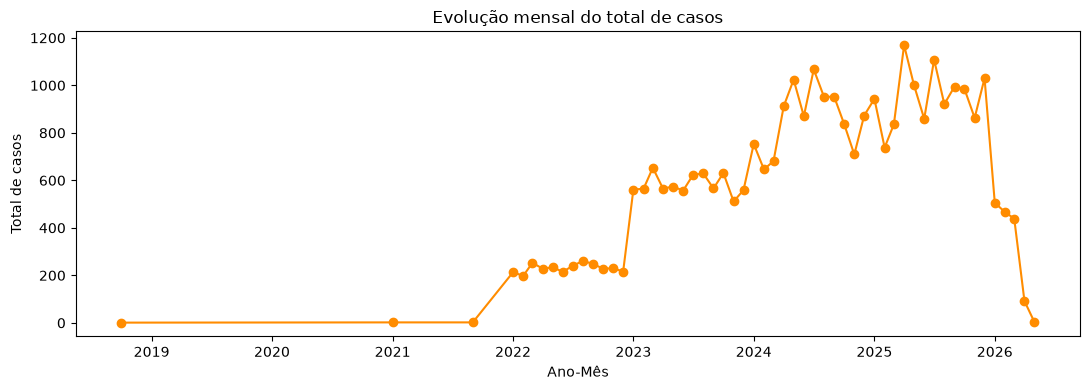

In [48]:
plt.figure(figsize=(11, 4))
plt.plot(casos_por_ano_mes['data_plot'], casos_por_ano_mes['total_casos'], marker='o', color='darkorange')
plt.title('Evolução mensal do total de casos')
plt.xlabel('Ano-Mês')
plt.ylabel('Total de casos')
plt.tight_layout()
plt.show()

O boxplot por mês mostra a variabilidade do número de casos entre diferentes anos para cada mês.

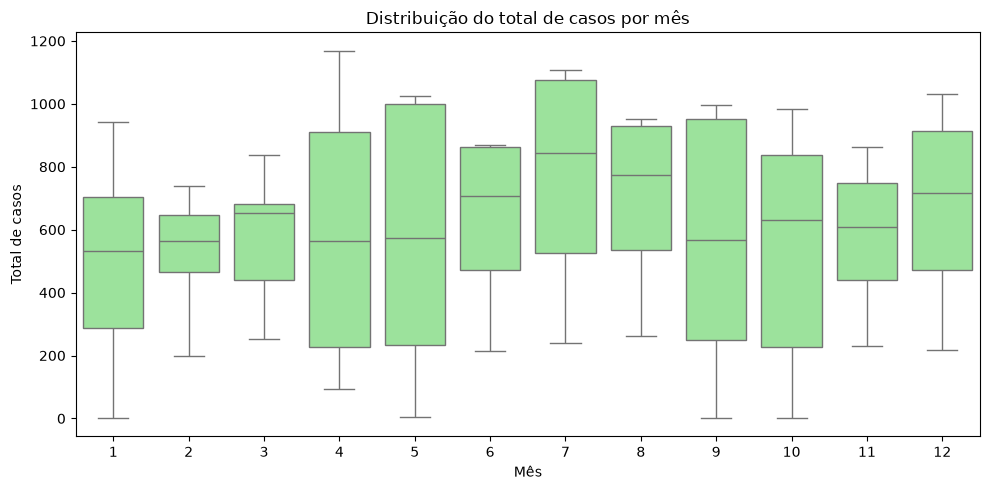

In [49]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=casos_por_ano_mes, x='mes_abertura', y='total_casos', color='lightgreen')
plt.title('Distribuição do total de casos por mês')
plt.xlabel('Mês')
plt.ylabel('Total de casos')
plt.tight_layout()
plt.show()

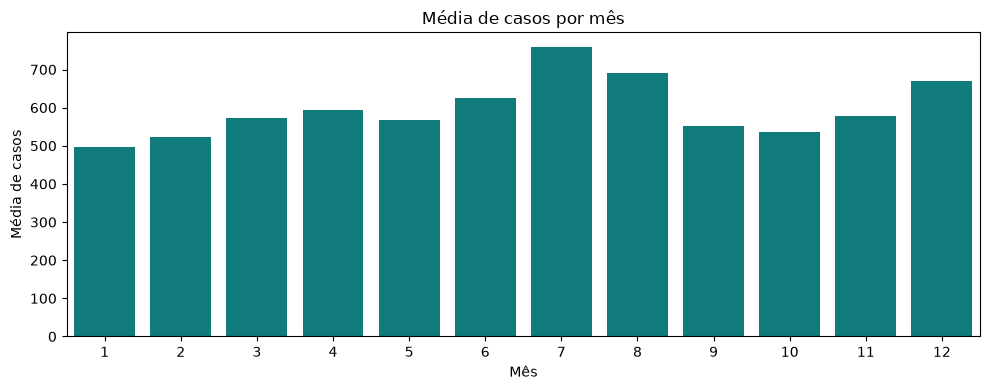

In [50]:
plt.figure(figsize=(10, 4))
sns.barplot(data=media_por_mes, x='mes_abertura', y='media_casos', color='darkcyan')
plt.title('Média de casos por mês')
plt.xlabel('Mês')
plt.ylabel('Média de casos')
plt.tight_layout()
plt.show()

A série temporal permite visualizar tendência de alta/queda no total de casos ao longo do tempo.